## Breast Cancer and Churn Prediction with KNN
Author: Dilia Navarro

# PART 1 - Breast Cancer Prediction

Step 1: Setting Up and Loading Data

In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
 
# Load the breast cancer dataset
print("Loading breast cancer dataset...")
cancer_data = load_breast_cancer()
 
# The dataset is a Bunch object with 'data', 'target', 'feature_names', etc.
print(f"\nDataset type: {type(cancer_data)}")
print(f"Number of samples: {len(cancer_data.data)}")
print(f"Number of features: {len(cancer_data.feature_names)}")
print(f"Target classes: {cancer_data.target_names}")
 
# Convert to DataFrame for easier manipulation
df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)
df['target'] = cancer_data.target
 
print("\nFirst few rows:")
print(df.head())
 
print("\nDataset info:")
print(df.info())
 
print("\nTarget distribution:")
print(df['target'].value_counts())
print(f"Malignant (1): {(df['target'] == 1).sum()}")
print(f"Benign (0): {(df['target'] == 0).sum()}")

Loading breast cancer dataset...

Dataset type: <class 'sklearn.utils._bunch.Bunch'>
Number of samples: 569
Number of features: 30
Target classes: ['malignant' 'benign']

First few rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520

Step 2: Data Exploration


BASIC STATISTICS
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.0

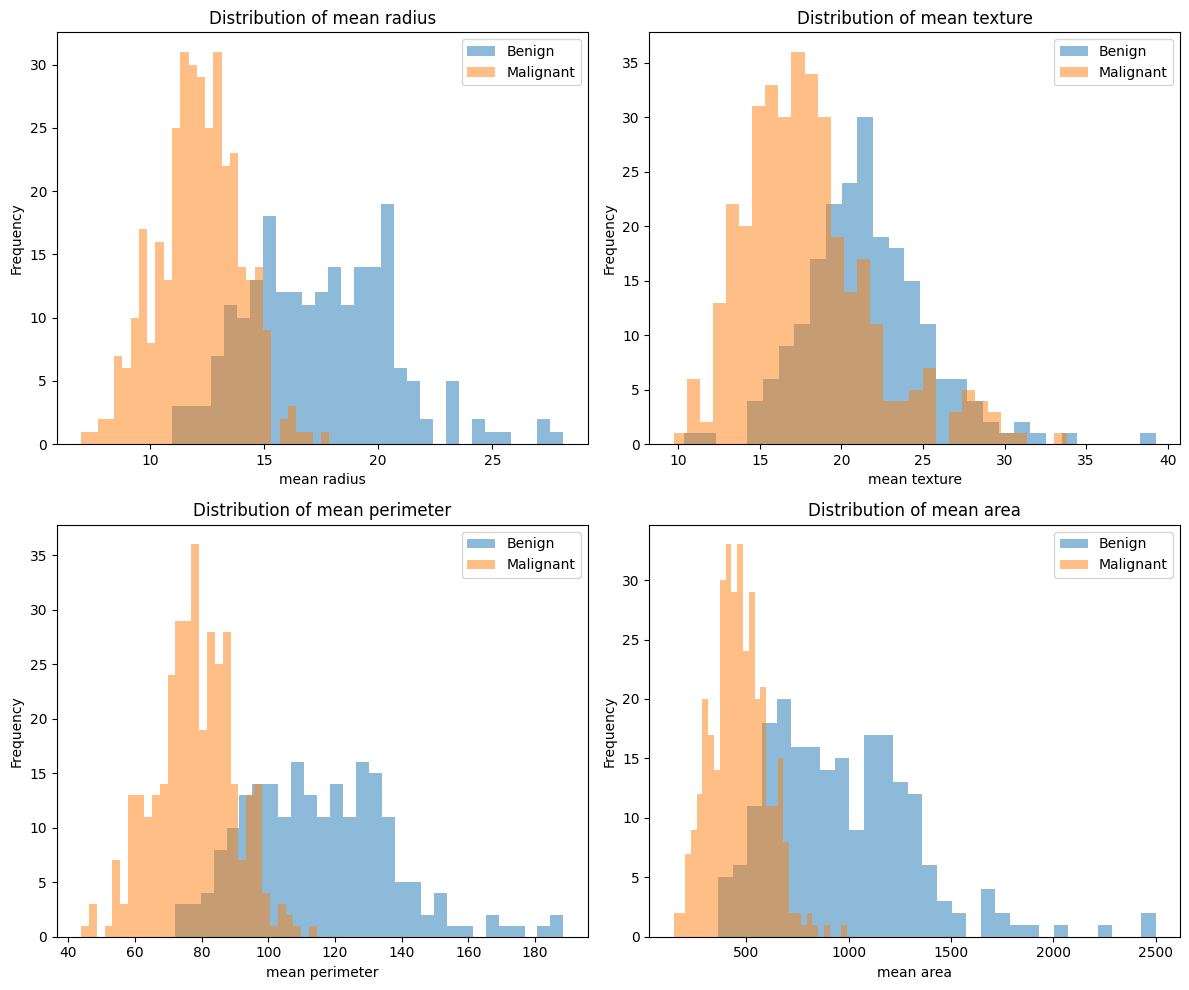

In [2]:
# Basic statistics
print("\n" + "="*50)
print("BASIC STATISTICS")
print("="*50)
print(df.describe())
 
# Check for missing values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✓ No missing values found!")
else:
    print(missing[missing > 0])
 
# Visualize feature distributions (select a few key features)
print("\n" + "="*50)
print("FEATURE DISTRIBUTIONS")
print("="*50)
 
# Select a few representative features to visualize
key_features = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.ravel()
 
for idx, feature in enumerate(key_features):
    axes[idx].hist(df[df['target'] == 0][feature], alpha=0.5, label='Benign', bins=30)
    axes[idx].hist(df[df['target'] == 1][feature], alpha=0.5, label='Malignant', bins=30)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].set_title(f'Distribution of {feature}')
    axes[idx].legend()
 
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
print("Saved visualization to 'feature_distributions.png'")
plt.show()

Step 3: Splitting the Data

In [3]:
# Separate features and target
X = df.drop('target', axis=1)  # All columns except 'target'
y = df['target']  # Target column
 
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
 
# Split into training and testing sets
# random_state ensures reproducibility
# stratify=y ensures both sets have similar class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)
 
print("\n" + "="*50)
print("DATA SPLIT")
print("="*50)
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Test set size: {X_test.shape[0]} samples")
print(f"Training features: {X_train.shape[1]}")
print(f"Test features: {X_test.shape[1]}")
 
# Verify class distribution in both sets
print("\nTraining set target distribution:")
print(y_train.value_counts())
print(f"  Benign (0): {(y_train == 0).sum()} ({(y_train == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_train == 1).sum()} ({(y_train == 1).mean()*100:.1f}%)")
 
print("\nTest set target distribution:")
print(y_test.value_counts())
print(f"  Benign (0): {(y_test == 0).sum()} ({(y_test == 0).mean()*100:.1f}%)")
print(f"  Malignant (1): {(y_test == 1).sum()} ({(y_test == 1).mean()*100:.1f}%)")

Features shape: (569, 30)
Target shape: (569,)

DATA SPLIT
Training set size: 455 samples
Test set size: 114 samples
Training features: 30
Test features: 30

Training set target distribution:
target
1    285
0    170
Name: count, dtype: int64
  Benign (0): 170 (37.4%)
  Malignant (1): 285 (62.6%)

Test set target distribution:
target
1    72
0    42
Name: count, dtype: int64
  Benign (0): 42 (36.8%)
  Malignant (1): 72 (63.2%)


Step 4: Training the KNN Model

In [6]:
# Create KNN classifier
# n_neighbors=5 means the model will look at the 5 nearest neighbors to make a prediction
 
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
 
print("KNN classifier trained successfully!")
print(f"Number of neighbors (k): {knn.n_neighbors}")

# Make predictions
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
 
print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")
 


KNN classifier trained successfully!
Number of neighbors (k): 5

Training predictions: 455
Test predictions: 114


Step 5: Making Predictions

From the student portal:

In [7]:
# Make predictions
y_train_pred = knn.predict(X_train)
y_test_pred = knn.predict(X_test)
 
print(f"\nTraining predictions: {len(y_train_pred)}")
print(f"Test predictions: {len(y_test_pred)}")


Training predictions: 455
Test predictions: 114


Prediction code checked with Claude

In [ ]:
print("=" * 50)
print("PREDICTIONS ON TEST SET")
print("=" * 50)

# 1. Make predictions on the test set
y_test_pred = knn.predict(X_test)

# 2. Compare predictions vs actual values
comparison_df = pd.DataFrame({
    'Actual':     y_test.values,
    'Predicted':  y_test_pred,
    'Correct':    y_test.values == y_test_pred
})

# Map numeric labels to readable names
label_map = {0: 'Benign', 1: 'Malignant'}
comparison_df['Actual Label']    = comparison_df['Actual'].map(label_map)
comparison_df['Predicted Label'] = comparison_df['Predicted'].map(label_map)
comparison_df['Result']          = comparison_df['Correct'].map({True: '✅ Correct', False: '❌ Wrong'})

# 3. Show a few examples
print("\nSample Predictions (first 10 test cases):")
print("-" * 60)
print(f"{'#':<5} {'Actual':<12} {'Predicted':<12} {'Result'}")
print("-" * 60)
for i, row in comparison_df.head(10).iterrows():
    print(f"{i:<5} {row['Actual Label']:<12} {row['Predicted Label']:<12} {row['Result']}")

# 4. Overall summary
total      = len(comparison_df)
correct    = comparison_df['Correct'].sum()
wrong      = total - correct
accuracy   = correct / total * 100

print("\n" + "=" * 50)
print("PREDICTION SUMMARY")
print("=" * 50)
print(f"  Total test samples:   {total}")
print(f"  Correct predictions:  {correct}  ({accuracy:.1f}%)")
print(f"  Wrong predictions:    {wrong}  ({100 - accuracy:.1f}%)")

# 5. Show misclassified examples
print("\n" + "=" * 50)
print("MISCLASSIFIED EXAMPLES")
print("=" * 50)
wrong_df = comparison_df[comparison_df['Correct'] == False]
if len(wrong_df) == 0:
    print("No misclassifications found!")
else:
    print(f"Found {len(wrong_df)} misclassified samples:\n")
    for i, row in wrong_df.iterrows():
        print(f"  Sample #{i}: Actual={row['Actual Label']}, Predicted={row['Predicted Label']}")

PREDICTIONS ON TEST SET

Sample Predictions (first 10 test cases):
------------------------------------------------------------
#     Actual       Predicted    Result
------------------------------------------------------------
0     Benign       Benign       ✅ Correct
1     Malignant    Malignant    ✅ Correct
2     Benign       Benign       ✅ Correct
3     Malignant    Benign       ❌ Wrong
4     Benign       Benign       ✅ Correct
5     Malignant    Malignant    ✅ Correct
6     Malignant    Malignant    ✅ Correct
7     Benign       Benign       ✅ Correct
8     Benign       Benign       ✅ Correct
9     Benign       Benign       ✅ Correct

PREDICTION SUMMARY
  Total test samples:   114
  Correct predictions:  104  (91.2%)
  Wrong predictions:    10  (8.8%)

MISCLASSIFIED EXAMPLES
Found 10 misclassified samples:

  Sample #3: Actual=Malignant, Predicted=Benign
  Sample #16: Actual=Malignant, Predicted=Benign
  Sample #25: Actual=Malignant, Predicted=Benign
  Sample #35: Actual=Benign, Pr

Step 6: Evaluating Model Performance

In [8]:
# Calculate metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_confusion = confusion_matrix(y_test, y_test_pred)
 
print("=== Model Performance ===")
print(f"\nTraining Accuracy: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Test Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
print(f"\nTest Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
 
print("\n=== Confusion Matrix ===")
print("                Predicted")
print("              Benign  Malignant")
print(f"Actual Benign    {test_confusion[0,0]:4d}      {test_confusion[0,1]:4d}")
print(f"      Malignant  {test_confusion[1,0]:4d}      {test_confusion[1,1]:4d}")
 
print("\n=== Classification Report ===")
print(classification_report(y_test, y_test_pred, target_names=cancer_data.target_names))

=== Model Performance ===

Training Accuracy: 0.9473 (94.73%)
Test Accuracy: 0.9123 (91.23%)

Test Precision: 0.9429
Test Recall: 0.9167

=== Confusion Matrix ===
                Predicted
              Benign  Malignant
Actual Benign      38         4
      Malignant     6        66

=== Classification Report ===
              precision    recall  f1-score   support

   malignant       0.86      0.90      0.88        42
      benign       0.94      0.92      0.93        72

    accuracy                           0.91       114
   macro avg       0.90      0.91      0.91       114
weighted avg       0.91      0.91      0.91       114



Analysis:
•	Total correct: 38 + 66 = 104 out of 114 → ~91.2% accuracy
•	Precision: 66 / (66 + 4) = 94.3% → when it predicts Malignant, it's usually right
•	Recall: 66 / (66 + 6) = 91.7% → it catches most of the actual Malignant cases

In cancer detection, the recall is critical, as 6 cases were predicted as benign when htey were in fact malignant. This needs to be improved.

Step 7: Experimenting with Different K Values


EXPERIMENTING WITH DIFFERENT K VALUES
K= 1: Accuracy=0.9211, Precision=0.9565, Recall=0.9167
K= 3: Accuracy=0.9298, Precision=0.9444, Recall=0.9444
K= 5: Accuracy=0.9123, Precision=0.9429, Recall=0.9167
K= 7: Accuracy=0.9298, Precision=0.9444, Recall=0.9444
K= 9: Accuracy=0.9386, Precision=0.9452, Recall=0.9583
K=11: Accuracy=0.9386, Precision=0.9452, Recall=0.9583

Best K value: 9 (Accuracy: 0.9386)

Saved visualization to 'knn_k_comparison.png'


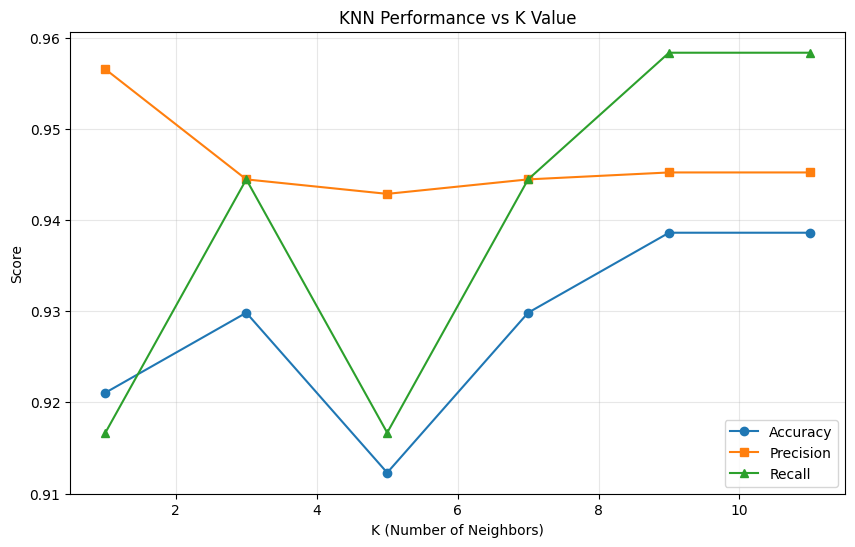

In [9]:
# Experiment with different K values
print("\n" + "="*50)
print("EXPERIMENTING WITH DIFFERENT K VALUES")
print("="*50)
 
k_values = [1, 3, 5, 7, 9, 11]
results = []
 
for k in k_values:
    # Create and train model
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train, y_train)
    
    # Make predictions
    y_pred_temp = knn_temp.predict(X_test)
    
    # Calculate accuracy
    acc = accuracy_score(y_test, y_pred_temp)
    prec = precision_score(y_test, y_pred_temp)
    rec = recall_score(y_test, y_pred_temp)
    
    results.append({
        'K': k,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec
    })
    
    print(f"K={k:2d}: Accuracy={acc:.4f}, Precision={prec:.4f}, Recall={rec:.4f}")
 
# Find best K
results_df = pd.DataFrame(results)
best_k = results_df.loc[results_df['Accuracy'].idxmax(), 'K']
print(f"\nBest K value: {best_k} (Accuracy: {results_df['Accuracy'].max():.4f})")
 
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(results_df['K'], results_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(results_df['K'], results_df['Precision'], marker='s', label='Precision')
plt.plot(results_df['K'], results_df['Recall'], marker='^', label='Recall')
plt.xlabel('K (Number of Neighbors)')
plt.ylabel('Score')
plt.title('KNN Performance vs K Value')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('knn_k_comparison.png', dpi=150, bbox_inches='tight')
print("\nSaved visualization to 'knn_k_comparison.png'")
plt.show()

# PART 2 - Customer Churn Prediction

# Step 1: Load and Explore the Data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# 1.1 Load the Dataset


DATA_DIR = Path("data")
CSV_FILE = DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
JSON_FILE = DATA_DIR / "WA_Fn-UseC_-Telco-Customer-Churn.json" #I did this thinking that I might need it in the end, but it wasn't used.
 
# Create data directory if it doesn't exist
DATA_DIR.mkdir(exist_ok=True)
 
print("Project setup complete!")
print(f"Data directory: {DATA_DIR}")
print(f"CSV file location: {CSV_FILE}")

Project setup complete!
Data directory: data
CSV file location: data\WA_Fn-UseC_-Telco-Customer-Churn.csv


In [3]:
df = pd.read_csv(CSV_FILE)
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
CSV_FILE

WindowsPath('data/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [5]:
# 1.2 Basic Exploration
print("\n" + "="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"  Shape:    {df.shape[0]} rows  x  {df.shape[1]} columns")

print("\n--- COLUMNS & DATA TYPES ---")
print(df.dtypes.to_string())
print("\n--- FIRST 5 ROWS ---")
print(df.head())

print("\n--- BASIC STATISTICS ---")
print(df.describe().T)


DATASET OVERVIEW
  Shape:    7043 rows  x  21 columns

--- COLUMNS & DATA TYPES ---
customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str

--- FIRST 5 ROWS ---
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2  

In [6]:
# 1.3 Missing Values
print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)
missing = df.isnull().sum()
if missing.sum() == 0:
    print("✅ No missing values found!")
else:
    print(missing[missing > 0])


MISSING VALUES
✅ No missing values found!


Note: Following Claude's recommendation, I checked for missing values again and found some. These can be found in the Data Preprocessing step.

In [7]:
# 1.4 Target Distribution (Churn)
print("\n" + "="*50)
print("TARGET DISTRIBUTION: CHURN")
print("="*50)

churn_counts  = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

for label in churn_counts.index:
    bar = '█' * int(churn_percent[label] / 2)
    print(f"  {label:<10} {churn_counts[label]:>5}  ({churn_percent[label]:.1f}%)  {bar}")



TARGET DISTRIBUTION: CHURN
  No          5174  (73.5%)  ████████████████████████████████████
  Yes         1869  (26.5%)  █████████████



✅ Visualization saved to: data/churn_exploration.png


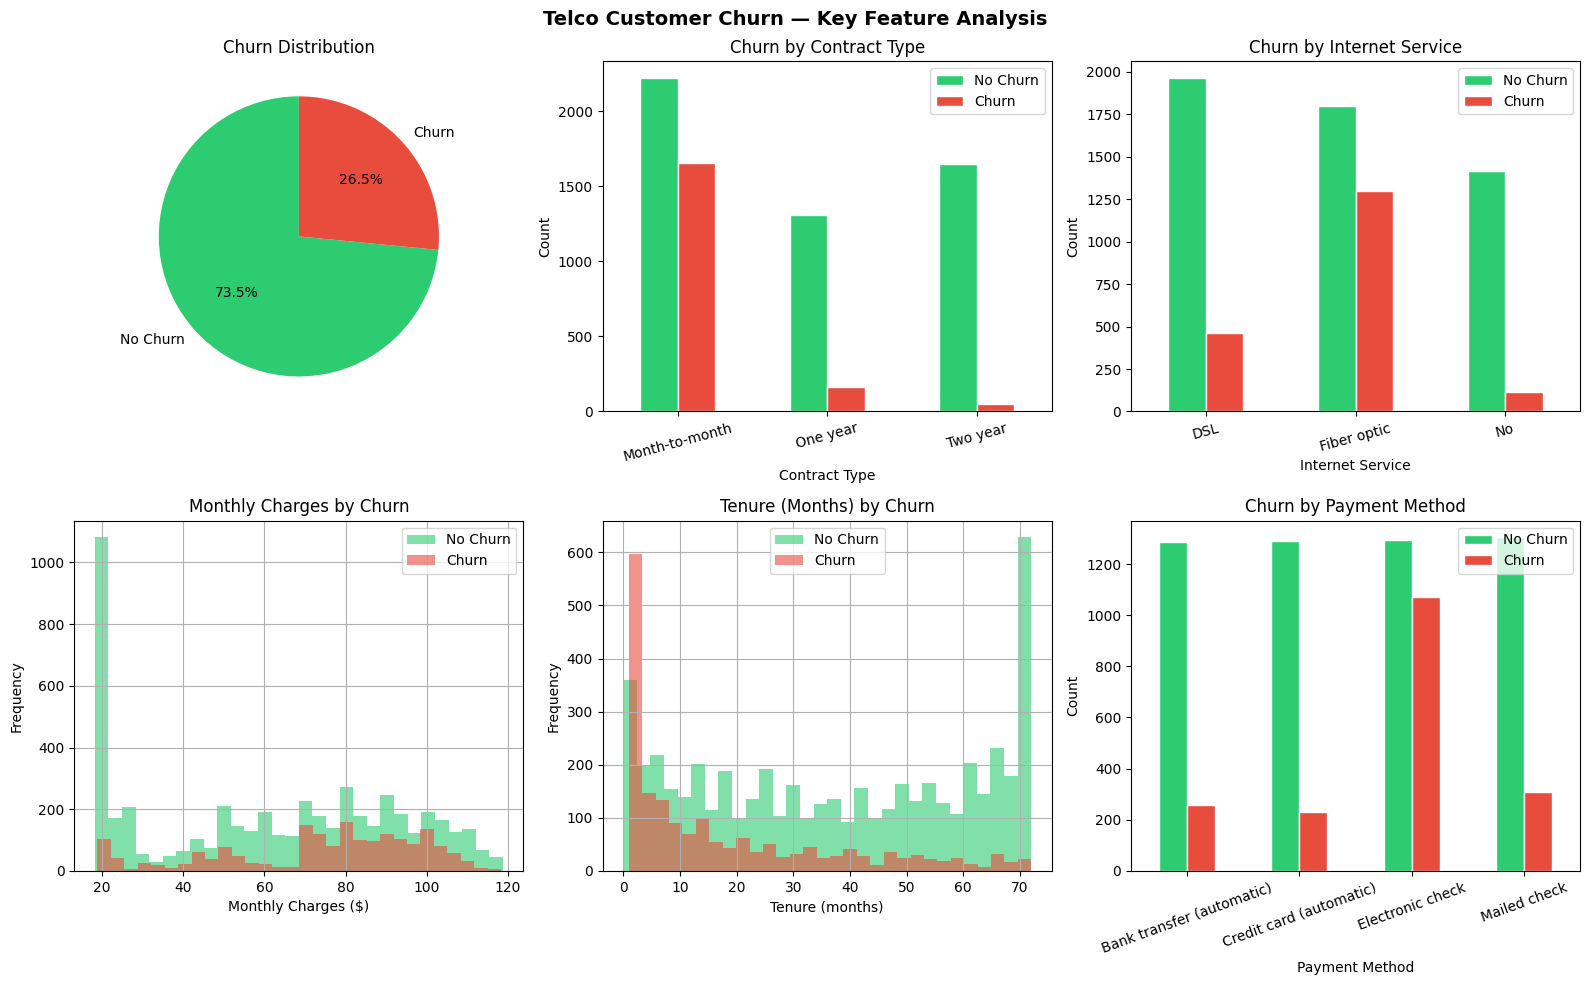


KEY INSIGHTS SUMMARY
  Total customers:     7043
  Churned:             1869  (26.5%)
  Retained:            5174  (73.5%)
  Avg Monthly Charges: $64.76
  Avg Tenure:          32.4 months
  Avg Total Charges:   $2283.30


In [8]:
df = pd.read_csv(Path('data/WA_Fn-UseC_-Telco-Customer-Churn.csv'))

# 1.5 Visualizations
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Telco Customer Churn — Key Feature Analysis', fontsize=14, fontweight='bold')

# --- Plot 1: Churn Distribution ---
ax1 = axes[0, 0]
churn_counts.plot.pie(
    ax=ax1, autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c'],
    startangle=90, labels=['No Churn', 'Churn']
)
ax1.set_title('Churn Distribution')
ax1.set_ylabel('')

# --- Plot 2: Churn by Contract Type ---
ax2 = axes[0, 1]
df.groupby(['Contract', 'Churn']).size().unstack().plot(
    kind='bar', ax=ax2, color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax2.set_title('Churn by Contract Type')
ax2.set_xlabel('Contract Type')
ax2.set_ylabel('Count')
ax2.tick_params(axis='x', rotation=15)
ax2.legend(['No Churn', 'Churn'])

# --- Plot 3: Churn by Internet Service ---
ax3 = axes[0, 2]
df.groupby(['InternetService', 'Churn']).size().unstack().plot(
    kind='bar', ax=ax3, color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax3.set_title('Churn by Internet Service')
ax3.set_xlabel('Internet Service')
ax3.set_ylabel('Count')
ax3.tick_params(axis='x', rotation=15)
ax3.legend(['No Churn', 'Churn'])

# --- Plot 4: Monthly Charges Distribution ---
ax4 = axes[1, 0]
df[df['Churn'] == 'No']['MonthlyCharges'].hist(ax=ax4, bins=30, alpha=0.6, color='#2ecc71', label='No Churn')
df[df['Churn'] == 'Yes']['MonthlyCharges'].hist(ax=ax4, bins=30, alpha=0.6, color='#e74c3c', label='Churn')
ax4.set_title('Monthly Charges by Churn')
ax4.set_xlabel('Monthly Charges ($)')
ax4.set_ylabel('Frequency')
ax4.legend()

# --- Plot 5: Tenure Distribution ---
ax5 = axes[1, 1]
df[df['Churn'] == 'No']['tenure'].hist(ax=ax5, bins=30, alpha=0.6, color='#2ecc71', label='No Churn')
df[df['Churn'] == 'Yes']['tenure'].hist(ax=ax5, bins=30, alpha=0.6, color='#e74c3c', label='Churn')
ax5.set_title('Tenure (Months) by Churn')
ax5.set_xlabel('Tenure (months)')
ax5.set_ylabel('Frequency')
ax5.legend()

# --- Plot 6: Churn by Payment Method ---
ax6 = axes[1, 2]
df.groupby(['PaymentMethod', 'Churn']).size().unstack().plot(
    kind='bar', ax=ax6, color=['#2ecc71', '#e74c3c'], edgecolor='white')
ax6.set_title('Churn by Payment Method')
ax6.set_xlabel('Payment Method')
ax6.set_ylabel('Count')
ax6.tick_params(axis='x', rotation=20)
ax6.legend(['No Churn', 'Churn'])

plt.tight_layout()
plt.savefig('data/churn_exploration.png', dpi=150, bbox_inches='tight')
print("\n✅ Visualization saved to: data/churn_exploration.png")
plt.show()


# 1.6 Key Insights Summary
print("\n" + "="*50)
print("KEY INSIGHTS SUMMARY")
print("="*50)
print(f"  Total customers:     {len(df)}")
print(f"  Churned:             {(df['Churn'] == 'Yes').sum()}  ({(df['Churn'] == 'Yes').mean()*100:.1f}%)")
print(f"  Retained:            {(df['Churn'] == 'No').sum()}  ({(df['Churn'] == 'No').mean()*100:.1f}%)")
print(f"  Avg Monthly Charges: ${df['MonthlyCharges'].mean():.2f}")
print(f"  Avg Tenure:          {df['tenure'].mean():.1f} months")
print(f"  Avg Total Charges:   ${pd.to_numeric(df['TotalCharges'], errors='coerce').mean():.2f}")

# Step 2: Data Preprocessing

In [53]:
df = pd.read_csv(Path('data/WA_Fn-UseC_-Telco-Customer-Churn.csv'))
print("✅ Fresh data reloaded!") #was getting an error, so to make sure that it does not happen again added this refresh here


# 2.1 Missing Values — Already confirmed none, but will be double-checked
print("\n--- 2.1 Missing Values Check ---")
# TotalCharges can have hidden spaces — fix it first
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
newly_missing = df['TotalCharges'].isnull().sum()

if newly_missing > 0:
    print(f"⚠️  Found {newly_missing} hidden missing values in TotalCharges → filling with median")
    df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)
else:
    print("✅ No missing values found!")



# 2.2 Convert Target to Binary (0/1)
print("\n--- 2.2 Target Encoding ---")

df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print("  Churn column converted:  Yes → 1  |  No → 0")
print(f"  Churned    (1): {df['Churn'].sum()}")
print(f"  Retained   (0): {(df['Churn'] == 0).sum()}")



# 2.3 Encode Categorical Variables
print("\n--- 2.3 Categorical Encoding ---")

# --- Binary columns (Yes/No) → 0/1 ---
binary_cols = [
    'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling'
]
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})
    print(f"  ✅ Binary encoded:   {col}")

# --- Gender → 0/1 ---
df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})
print(f"  ✅ Binary encoded:   gender  (Male=1, Female=0)")

# --- Multi-category columns → One-Hot Encoding ---
multi_cat_cols = [
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod'
]

df = pd.get_dummies(df, columns=multi_cat_cols, drop_first=True)
print(f"\n  ✅ One-Hot encoded:  {multi_cat_cols}")
print(f"\n  DataFrame shape after encoding: {df.shape}")



# 2.4 Drop Irrelevant Columns
print("\n--- 2.4 Drop Irrelevant Columns ---")

# customerID is just an identifier — not useful for prediction
df.drop(columns=['customerID'], inplace=True)
print("  ✅ Dropped: customerID (identifier, not a feature)")


# 2.5 Select Features (X) and Target (y)
print("\n--- 2.5 Feature & Target Separation ---")

y = df['Churn']                          # Target
X = df.drop(columns=['Churn'])           # All other columns = features

print(f"  Target (y):    'Churn'  →  {y.shape[0]} samples")
print(f"  Features (X):  {X.shape[1]} features  x  {X.shape[0]} samples")

print("\n  Feature list:")
for i, col in enumerate(X.columns, 1):
    print(f"    {i:>2}. {col}")


# 2.6 Summary
print("\n" + "=" * 50)
print("PREPROCESSING SUMMARY")
print("=" * 50)
print(f"  Original columns:        21")
print(f"  Final feature count:     {X.shape[1]}")
print(f"  Total samples:           {X.shape[0]}")
print(f"  Target balance:")
print(f"    Churned    (1): {y.sum()}  ({y.mean()*100:.1f}%)")
print(f"    Retained   (0): {(y==0).sum()}  ({(1 - y.mean())*100:.1f}%)")
print(f"\n  ✅ X and y are ready for modeling!")

✅ Fresh data reloaded!

--- 2.1 Missing Values Check ---
⚠️  Found 11 hidden missing values in TotalCharges → filling with median

--- 2.2 Target Encoding ---
  Churn column converted:  Yes → 1  |  No → 0
  Churned    (1): 1869
  Retained   (0): 5174

--- 2.3 Categorical Encoding ---
  ✅ Binary encoded:   Partner
  ✅ Binary encoded:   Dependents
  ✅ Binary encoded:   PhoneService
  ✅ Binary encoded:   PaperlessBilling
  ✅ Binary encoded:   gender  (Male=1, Female=0)

  ✅ One-Hot encoded:  ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']

  DataFrame shape after encoding: (7043, 32)

--- 2.4 Drop Irrelevant Columns ---
  ✅ Dropped: customerID (identifier, not a feature)

--- 2.5 Feature & Target Separation ---
  Target (y):    'Churn'  →  7043 samples
  Features (X):  30 features  x  7043 samples

  Feature list:
     1. gender
     2. SeniorCitizen
     3. Partner
   

Notes: 

Churn column converted:  Yes → 1 Churned |  No → 0 Retained

x and y separation:
Target (y): 'Churn'  
Features (X): 30 features  

# Step 3: Split the Data

In [54]:
# Split data into 80% train / 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% for testing
    random_state=42,      # reproducibility
    stratify=y            # maintain class distribution
)


# Verify the split
print(f"\n  Total samples:     {len(X)}")
print(f"  Training set:      {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"  Test set:          {X_test.shape[0]} samples  ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"  Features:          {X_train.shape[1]}")

# Verify class distribution is maintained in both sets
print("\n--- Class Distribution Check ---")
print(f"  {'Set':<12} {'Retained (0)':>15} {'Churned (1)':>15}")
print(f"  {'-'*42}")
print(f"  {'Original':<12} {(y==0).mean()*100:>13.1f}%  {y.mean()*100:>13.1f}%")
print(f"  {'Train':<12} {(y_train==0).mean()*100:>13.1f}%  {y_train.mean()*100:>13.1f}%")
print(f"  {'Test':<12} {(y_test==0).mean()*100:>13.1f}%  {y_test.mean()*100:>13.1f}%")



  Total samples:     7043
  Training set:      5634 samples  (80%)
  Test set:          1409 samples  (20%)
  Features:          30

--- Class Distribution Check ---
  Set             Retained (0)     Churned (1)
  ------------------------------------------
  Original              73.5%           26.5%
  Train                 73.5%           26.5%
  Test                  73.5%           26.5%


# Step 4: Train a KNN Model

In [ ]:
# Fix: Handle any remaining NaN values in X_train and X_test
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

print(f"  NaNs remaining in X_train: {pd.isnull(X_train_imp).sum().sum()}")
print(f"  NaNs remaining in X_test:  {pd.isnull(X_test_imp).sum().sum()}")

# Create KNN classifier with k=5
knn = KNeighborsClassifier(n_neighbors=5)

# Train the model on the imputed training data
knn.fit(X_train_imp, y_train)

print("✅ KNN model trained successfully!")
print(f"   Number of neighbors (k): {knn.n_neighbors}")
print(f"   Training samples used:   {X_train_imp.shape[0]}")
print(f"   Features used:           {X_train_imp.shape[1]}")

  NaNs remaining in X_train: 0
  NaNs remaining in X_test:  0
✅ KNN model trained successfully!
   Number of neighbors (k): 5
   Training samples used:   5634
   Features used:           30


# Step 5: Make Predictions and Evaluate

In [55]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             confusion_matrix, classification_report, ConfusionMatrixDisplay)

# 5.1 Make Predictions
y_train_pred = knn.predict(X_train_imp)
y_test_pred  = knn.predict(X_test_imp)

print("✅ Predictions complete!")
print(f"   Training predictions: {len(y_train_pred)}")
print(f"   Test predictions:     {len(y_test_pred)}")

# 5.2 Metrics
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy  = accuracy_score(y_test,  y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall    = recall_score(y_test,    y_test_pred)

print("\n" + "="*50)
print("MODEL PERFORMANCE METRICS")
print("="*50)
print(f"  Training Accuracy:  {train_accuracy:.4f}  ({train_accuracy*100:.2f}%)")
print(f"  Test Accuracy:      {test_accuracy:.4f}  ({test_accuracy*100:.2f}%)")
print(f"  Test Precision:     {test_precision:.4f}")
print(f"  Test Recall:        {test_recall:.4f}")

# 5.3 Confusion Matrix
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
print(f"                  Predicted")
print(f"                  No Churn   Churned")
print(f"  Actual No Churn   {tn:>5}     {fp:>5}")
print(f"  Actual Churned    {fn:>5}     {tp:>5}")
print(f"\n  True  Negatives (TN): {tn}  — correctly predicted No Churn")
print(f"  False Positives (FP): {fp}  — predicted Churn, actually No Churn")
print(f"  False Negatives (FN): {fn}  — predicted No Churn, actually Churned  ⚠️")
print(f"  True  Positives (TP): {tp}  — correctly predicted Churn")

# 5.4 Classification Report
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_test_pred, target_names=['No Churn', 'Churned']))

# 5.5 Interpretation
print("="*50)
print("INTERPRETATION")
print("="*50)
gap = (train_accuracy - test_accuracy) * 100
print(f"  Accuracy gap (train - test): {gap:.1f}% → {'⚠️ possible overfitting' if gap > 5 else '✅ model generalises well'}")
print(f"\n  Precision {test_precision*100:.1f}%: when the model predicts churn, it is correct {test_precision*100:.1f}% of the time.")
print(f"  Recall    {test_recall*100:.1f}%: the model catches {test_recall*100:.1f}% of all actual churners.")
print(f"\n  ⚠️  False Negatives = {fn}: {fn} churners were missed (predicted as No Churn).")
print(f"      In a business context this is costly — these customers leave undetected.")
print(f"  💡 To reduce FN, consider lowering the decision threshold or tuning k.")

✅ Predictions complete!
   Training predictions: 5634
   Test predictions:     1409

MODEL PERFORMANCE METRICS
  Training Accuracy:  0.8277  (82.77%)
  Test Accuracy:      0.7658  (76.58%)
  Test Precision:     0.5791
  Test Recall:        0.4305

CONFUSION MATRIX
                  Predicted
                  No Churn   Churned
  Actual No Churn     918       117
  Actual Churned      213       161

  True  Negatives (TN): 918  — correctly predicted No Churn
  False Positives (FP): 117  — predicted Churn, actually No Churn
  False Negatives (FN): 213  — predicted No Churn, actually Churned  ⚠️
  True  Positives (TP): 161  — correctly predicted Churn

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    No Churn       0.81      0.89      0.85      1035
     Churned       0.58      0.43      0.49       374

    accuracy                           0.77      1409
   macro avg       0.70      0.66      0.67      1409
weighted avg       0.75      0.77      0.75    

# Step 6: Experiment and Improve

  K      Train Acc   Test Acc  Precision     Recall
  1        0.9980     0.7119     0.4570     0.4545
  3        0.8600     0.7622     0.5657     0.4492
  5        0.8277     0.7658     0.5791     0.4305
  7        0.8184     0.7814     0.6260     0.4385
  9        0.8151     0.7892     0.6559     0.4332
  11       0.8111     0.7871     0.6609     0.4064
  15       0.8056     0.7899     0.6741     0.4037

  🏆 Best K by Test Accuracy: k=15  (78.99%)
  🎯 Best K by Recall:        k=1  (45.45%)

✅ Saved: data/knn_k_comparison.png


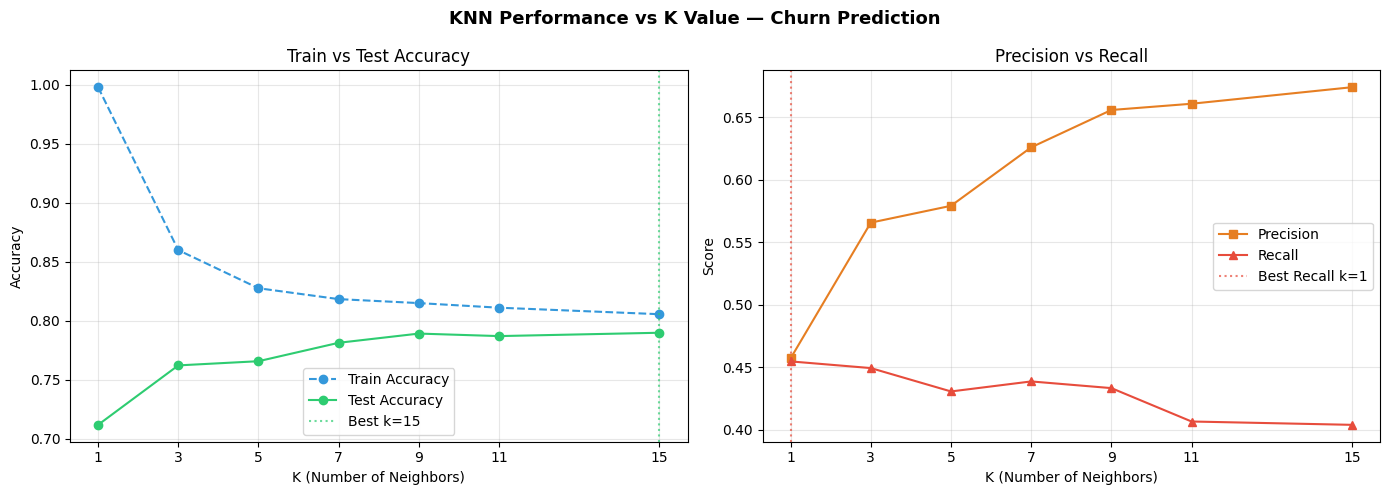


FINAL MODEL  —  k = 15
              precision    recall  f1-score   support

    No Churn       0.81      0.93      0.87      1035
     Churned       0.67      0.40      0.51       374

    accuracy                           0.79      1409
   macro avg       0.74      0.67      0.69      1409
weighted avg       0.78      0.79      0.77      1409

FINDINGS & DOCUMENTATION
  k=1    TestAcc=71.2%  Recall=45.5%  Gap=28.6%  ⚠️  overfitting
  k=3    TestAcc=76.2%  Recall=44.9%  Gap=9.8%  ⚠️  overfitting
  k=5    TestAcc=76.6%  Recall=43.0%  Gap=6.2%  ⚠️  overfitting
  k=7    TestAcc=78.1%  Recall=43.9%  Gap=3.7%  ✅
  k=9    TestAcc=78.9%  Recall=43.3%  Gap=2.6%  ✅
  k=11   TestAcc=78.7%  Recall=40.6%  Gap=2.4%  ✅
  k=15   TestAcc=79.0%  Recall=40.4%  Gap=1.6%  ✅

  Key findings:
  • Low k (k=1): highest train accuracy but largest overfit gap.
  • As k increases: train accuracy drops, test accuracy stabilises → less overfitting.
  • Best test accuracy:  k=15
  • Best recall:         k=1  ← 

In [56]:
k_values = [1, 3, 5, 7, 9, 11, 15]
results   = []

print("="*65)
print(f"  {'K':<5} {'Train Acc':>10} {'Test Acc':>10} {'Precision':>10} {'Recall':>10}")
print("="*65)

for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(X_train_imp, y_train)

    y_train_k = knn_k.predict(X_train_imp)
    y_test_k  = knn_k.predict(X_test_imp)

    train_acc = accuracy_score(y_train, y_train_k)
    test_acc  = accuracy_score(y_test,  y_test_k)
    prec      = precision_score(y_test, y_test_k)
    rec       = recall_score(y_test,    y_test_k)

    results.append({
        'K':          k,
        'Train Acc':  train_acc,
        'Test Acc':   test_acc,
        'Precision':  prec,
        'Recall':     rec
    })

    print(f"  {k:<5} {train_acc:>9.4f}  {test_acc:>9.4f}  {prec:>9.4f}  {rec:>9.4f}")

print("="*65)

# 6.2 Results DataFrame
results_df = pd.DataFrame(results)

best_acc_idx = results_df['Test Acc'].idxmax()
best_rec_idx = results_df['Recall'].idxmax()
best_k_acc   = results_df.loc[best_acc_idx, 'K']
best_k_rec   = results_df.loc[best_rec_idx, 'K']

print(f"\n  🏆 Best K by Test Accuracy: k={int(best_k_acc)}  ({results_df.loc[best_acc_idx,'Test Acc']*100:.2f}%)")
print(f"  🎯 Best K by Recall:        k={int(best_k_rec)}  ({results_df.loc[best_rec_idx,'Recall']*100:.2f}%)")

# 6.3 Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KNN Performance vs K Value — Churn Prediction', fontsize=13, fontweight='bold')

# --- Plot 1: Accuracy (train vs test) ---
ax1 = axes[0]
ax1.plot(results_df['K'], results_df['Train Acc'], marker='o', linestyle='--',
         color='#3498db', label='Train Accuracy')
ax1.plot(results_df['K'], results_df['Test Acc'],  marker='o',
         color='#2ecc71', label='Test Accuracy')
ax1.axvline(best_k_acc, color='#2ecc71', linestyle=':', alpha=0.7,
            label=f'Best k={int(best_k_acc)}')
ax1.set_title('Train vs Test Accuracy')
ax1.set_xlabel('K (Number of Neighbors)')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(k_values)

# --- Plot 2: Precision vs Recall ---
ax2 = axes[1]
ax2.plot(results_df['K'], results_df['Precision'], marker='s',
         color='#e67e22', label='Precision')
ax2.plot(results_df['K'], results_df['Recall'],    marker='^',
         color='#e74c3c', label='Recall')
ax2.axvline(best_k_rec, color='#e74c3c', linestyle=':', alpha=0.7,
            label=f'Best Recall k={int(best_k_rec)}')
ax2.set_title('Precision vs Recall')
ax2.set_xlabel('K (Number of Neighbors)')
ax2.set_ylabel('Score')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(k_values)

plt.tight_layout()
plt.savefig('data/knn_k_comparison.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved: data/knn_k_comparison.png")
plt.show()

# 6.4 Retrain with Best K & Final Report
print("\n" + "="*50)
print(f"FINAL MODEL  —  k = {int(best_k_acc)}")
print("="*50)

knn_best = KNeighborsClassifier(n_neighbors=int(best_k_acc))
knn_best.fit(X_train_imp, y_train)
y_best_pred = knn_best.predict(X_test_imp)

print(classification_report(y_test, y_best_pred, target_names=['No Churn', 'Churned']))

# 6.5 Findings Summary
print("="*50)
print("FINDINGS & DOCUMENTATION")
print("="*50)
for _, row in results_df.iterrows():
    gap   = (row['Train Acc'] - row['Test Acc']) * 100
    flag  = "⚠️  overfitting" if gap > 5 else "✅"
    print(f"  k={int(row['K']):<3}  TestAcc={row['Test Acc']*100:.1f}%  "
          f"Recall={row['Recall']*100:.1f}%  Gap={gap:.1f}%  {flag}")

print(f"""
  Key findings:
  • Low k (k=1): highest train accuracy but largest overfit gap.
  • As k increases: train accuracy drops, test accuracy stabilises → less overfitting.
  • Best test accuracy:  k={int(best_k_acc)}
  • Best recall:         k={int(best_k_rec)}  ← preferred for churn (minimises missed churners)
  • Recommendation: use k={int(best_k_rec)} if business priority is catching churners,
    or k={int(best_k_acc)} if overall accuracy matters more.
""")

# Step 7: Analysis and Recommendations

7.1  MODEL ACCURACY SUMMARY
  Best K:          15
  Test Accuracy:   78.99%
  Precision:       67.41%
  Recall:          40.37%
  F1 Score:        50.50%

  Churners correctly caught:  151
  Churners missed (FN):       223  ⚠️
  False alarms    (FP):       73

7.2  FEATURE IMPORTANCE  (correlation with Churn)

  Top 10 features most correlated with Churn:

   1. tenure                                   0.3456  █████████████
   2. InternetService_Fiber optic              0.3127  ████████████
   3. PaymentMethod_Electronic check           0.3092  ████████████
   4. Contract_Two year                        0.3022  ████████████
   5. InternetService_No                       0.2289  █████████
   6. OnlineSecurity_No internet service       0.2289  █████████
   7. DeviceProtection_No internet service     0.2289  █████████
   8. TechSupport_No internet service          0.2289  █████████
   9. StreamingMovies_No internet service      0.2289  █████████
  10. StreamingTV_No internet service      

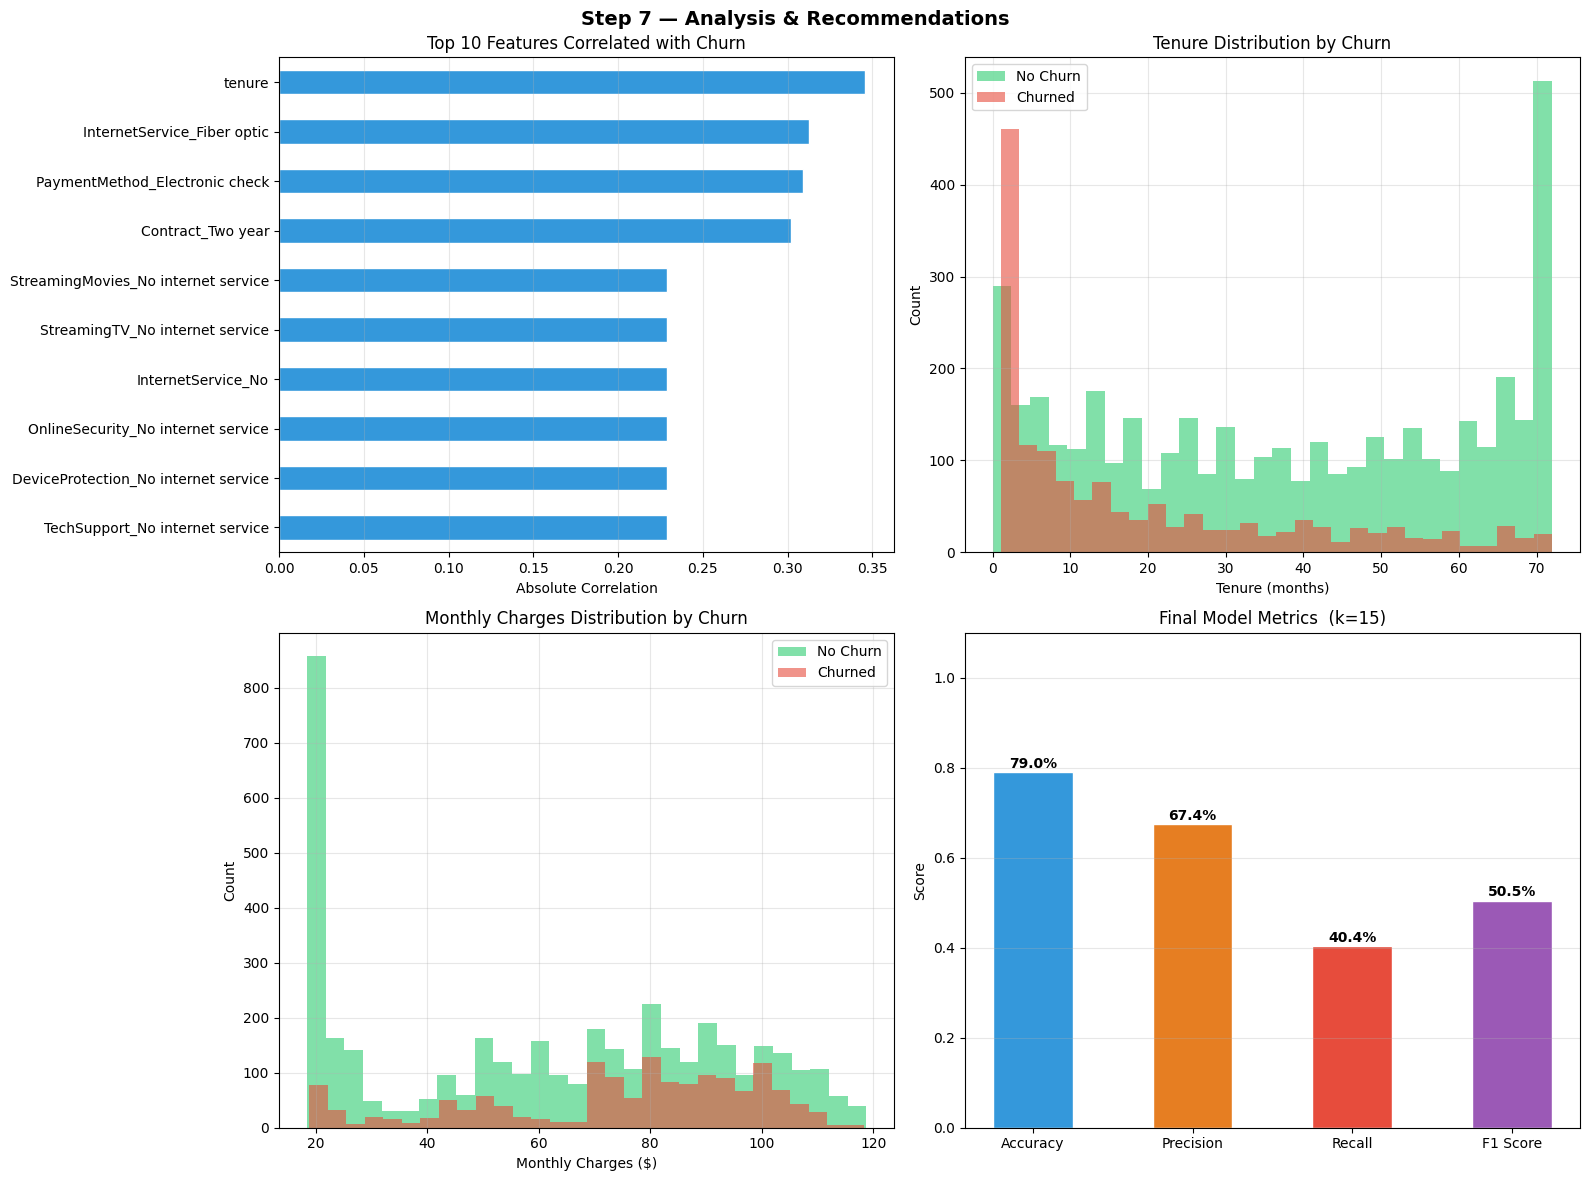


7.3  BUSINESS RECOMMENDATIONS

  Based on the model and feature analysis:

  1. TARGET SHORT-TENURE CUSTOMERS EARLY
     Churners tend to leave within the first few months.
     → Launch onboarding programmes and check-in calls
       during the first 3–6 months of a contract.

  2. REVIEW MONTH-TO-MONTH CONTRACTS
     Customers on monthly contracts churn far more often.
     → Offer discounts or loyalty perks to migrate them
       to 1- or 2-year contracts.

  3. ADDRESS HIGH MONTHLY CHARGES
     Higher charges correlate with churn.
     → Introduce tiered pricing, bundle discounts, or
       personalised offers for high-spend customers.

  4. DEPLOY THE MODEL AS AN EARLY-WARNING SYSTEM
     Run predictions monthly on the active customer base.
     → Flag high-risk customers for the retention team
       before they cancel.

  5. PRIORITISE RECALL OVER ACCURACY
     Missing a churner is costlier than a false alarm.
     → Choose the k with highest recall; a wrongly flagged
       cu

In [57]:
# 7.1 Model Accuracy Summary (best k from Step 6)
print("=" * 55)
print("7.1  MODEL ACCURACY SUMMARY")
print("=" * 55)

y_final_pred  = knn_best.predict(X_test_imp)
final_acc     = accuracy_score(y_test,  y_final_pred)
final_prec    = precision_score(y_test, y_final_pred)
final_rec     = recall_score(y_test,    y_final_pred)
final_f1      = 2 * (final_prec * final_rec) / (final_prec + final_rec)
cm            = confusion_matrix(y_test, y_final_pred)
tn, fp, fn, tp = cm.ravel()

print(f"  Best K:          {knn_best.n_neighbors}")
print(f"  Test Accuracy:   {final_acc*100:.2f}%")
print(f"  Precision:       {final_prec*100:.2f}%")
print(f"  Recall:          {final_rec*100:.2f}%")
print(f"  F1 Score:        {final_f1*100:.2f}%")
print(f"\n  Churners correctly caught:  {tp}")
print(f"  Churners missed (FN):       {fn}  ⚠️")
print(f"  False alarms    (FP):       {fp}")

# 7.2 Feature Importance via Correlation with Churn
print("\n" + "=" * 55)
print("7.2  FEATURE IMPORTANCE  (correlation with Churn)")
print("=" * 55)

# Rebuild full df with Churn for correlation analysis
X_analysis        = pd.DataFrame(X_train_imp, columns=X.columns)
X_analysis['Churn'] = y_train.values

correlations = (X_analysis.corr()['Churn']
                           .drop('Churn')
                           .abs()
                           .sort_values(ascending=False))

top_features = correlations.head(10)
print("\n  Top 10 features most correlated with Churn:\n")
for rank, (feat, corr) in enumerate(top_features.items(), 1):
    bar = '█' * int(corr * 40)
    print(f"  {rank:>2}. {feat:<40} {corr:.4f}  {bar}")


# 7.3 Visualisations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Step 7 — Analysis & Recommendations', fontsize=14, fontweight='bold')

# --- Plot 1: Top 10 Feature Correlations ---
ax1 = axes[0, 0]
top_features.sort_values().plot(kind='barh', ax=ax1, color='#3498db', edgecolor='white')
ax1.set_title('Top 10 Features Correlated with Churn')
ax1.set_xlabel('Absolute Correlation')
ax1.grid(True, alpha=0.3, axis='x')

# --- Plot 2: Tenure vs Churn ---
ax2 = axes[0, 1]
X_analysis[X_analysis['Churn'] == 0]['tenure'].hist(
    ax=ax2, bins=30, alpha=0.6, color='#2ecc71', label='No Churn')
X_analysis[X_analysis['Churn'] == 1]['tenure'].hist(
    ax=ax2, bins=30, alpha=0.6, color='#e74c3c', label='Churned')
ax2.set_title('Tenure Distribution by Churn')
ax2.set_xlabel('Tenure (months)')
ax2.set_ylabel('Count')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Plot 3: Monthly Charges vs Churn ---
ax3 = axes[1, 0]
X_analysis[X_analysis['Churn'] == 0]['MonthlyCharges'].hist(
    ax=ax3, bins=30, alpha=0.6, color='#2ecc71', label='No Churn')
X_analysis[X_analysis['Churn'] == 1]['MonthlyCharges'].hist(
    ax=ax3, bins=30, alpha=0.6, color='#e74c3c', label='Churned')
ax3.set_title('Monthly Charges Distribution by Churn')
ax3.set_xlabel('Monthly Charges ($)')
ax3.set_ylabel('Count')
ax3.legend()
ax3.grid(True, alpha=0.3)

# --- Plot 4: Metric comparison bar chart ---
ax4 = axes[1, 1]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values  = [final_acc, final_prec, final_rec, final_f1]
colors  = ['#3498db', '#e67e22', '#e74c3c', '#9b59b6']
bars    = ax4.bar(metrics, values, color=colors, edgecolor='white', width=0.5)
for bar, val in zip(bars, values):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val*100:.1f}%', ha='center', fontsize=10, fontweight='bold')
ax4.set_title(f'Final Model Metrics  (k={knn_best.n_neighbors})')
ax4.set_ylim(0, 1.1)
ax4.set_ylabel('Score')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('data/step7_analysis.png', dpi=150, bbox_inches='tight')
print("\n✅ Saved: data/step7_analysis.png")
plt.show()


# 7.4 Business Recommendations
print("\n" + "=" * 55)
print("7.3  BUSINESS RECOMMENDATIONS")
print("=" * 55)
print("""
  Based on the model and feature analysis:

  1. TARGET SHORT-TENURE CUSTOMERS EARLY
     Churners tend to leave within the first few months.
     → Launch onboarding programmes and check-in calls
       during the first 3–6 months of a contract.

  2. REVIEW MONTH-TO-MONTH CONTRACTS
     Customers on monthly contracts churn far more often.
     → Offer discounts or loyalty perks to migrate them
       to 1- or 2-year contracts.

  3. ADDRESS HIGH MONTHLY CHARGES
     Higher charges correlate with churn.
     → Introduce tiered pricing, bundle discounts, or
       personalised offers for high-spend customers.

  4. DEPLOY THE MODEL AS AN EARLY-WARNING SYSTEM
     Run predictions monthly on the active customer base.
     → Flag high-risk customers for the retention team
       before they cancel.

  5. PRIORITISE RECALL OVER ACCURACY
     Missing a churner is costlier than a false alarm.
     → Choose the k with highest recall; a wrongly flagged
       customer just receives a discount offer.
""")


# 7.5 Model Limitations
print("=" * 55)
print("7.4  MODEL LIMITATIONS")
print("=" * 55)
print(f"""
  1. KNN IS DISTANCE-BASED — SCALE SENSITIVE
     Features were not standardised (e.g. tenure 0–72 vs
     binary 0/1). Large-scale features dominate distance
     calculations, biasing the model.
     → Apply StandardScaler before training for fairer results.

  2. NO FEATURE IMPORTANCE SCORES
     KNN is a black-box model — it cannot directly rank
     which features drive churn. Correlation is used here
     as a proxy, but it only captures linear relationships.

  3. CLASS IMBALANCE (~26% churn vs ~74% no-churn)
     The model sees far more non-churners during training,
     which can bias it toward predicting "No Churn."
     → Consider SMOTE or class_weight adjustments.

  4. KNN SCALES POORLY
     Prediction requires computing distance to all {X_train_imp.shape[0]}
     training samples for every new customer — slow in
     production at scale.
     → Tree-based models (Random Forest, XGBoost) would be
       faster and likely more accurate for this dataset.

  5. STATIC SNAPSHOT
     The model was trained on a single snapshot of data.
     Customer behaviour changes over time.
     → Retrain regularly with fresh data.
""")